<a href="https://colab.research.google.com/github/saleemshahzad08/Applied-Python-Mini-Projects/blob/main/NumPy/Image_Processing_Simulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Image Processing Simulator**


---


**Topics: 2D/3D arrays, slicing, ufuncs, reshaping, broadcasting**

Simulate basic image operations on a grayscale image represented as a 2D NumPy array.
- Create a synthetic 64x64 "image" using np.random.randint(0, 256, (64, 64))
- Implement brightness adjustment: add scalar, clip to [0, 255]
- Implement contrast stretching: min-max normalization to [0, 255]
- Implement a 3x3 mean blur using manual sliding window approach
- Detect "edges" by computing gradient magnitude using np.diff
- Apply threshold segmentation using boolean indexing
- Flip horizontally and vertically using slicing
- Rotate 90 degrees using np.rot90

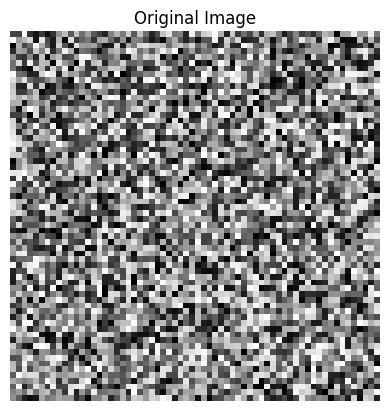

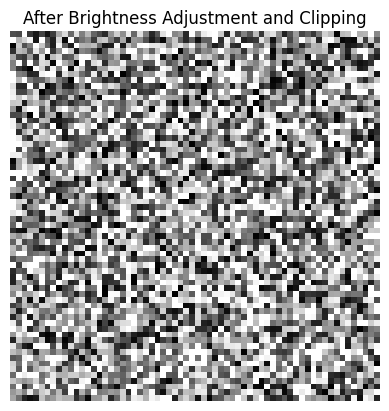

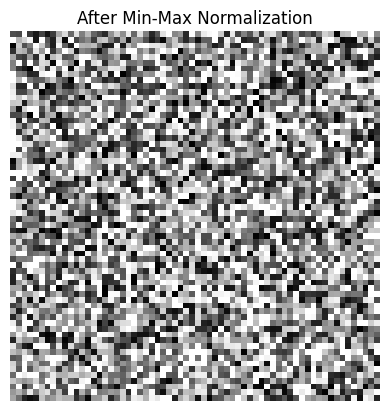

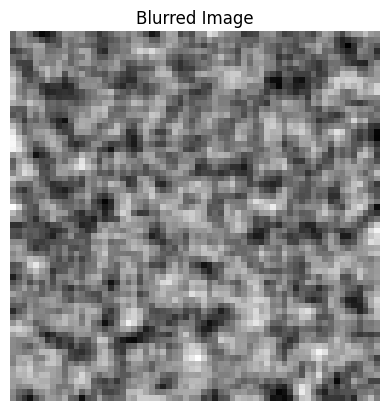

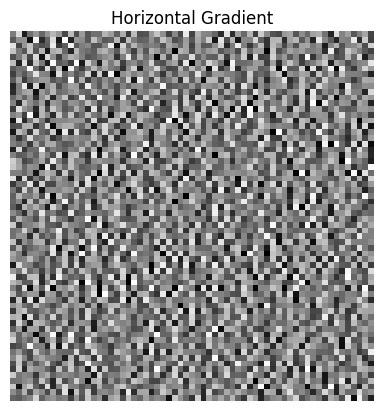

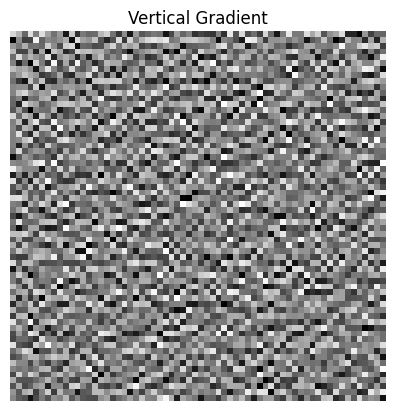

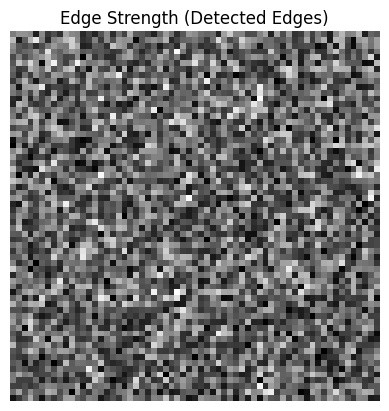

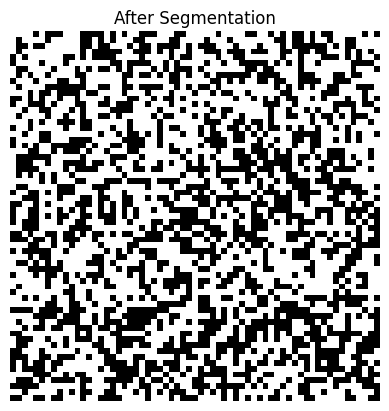

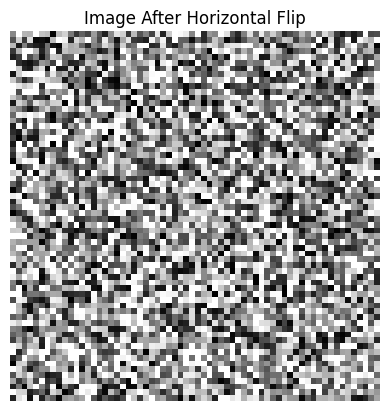

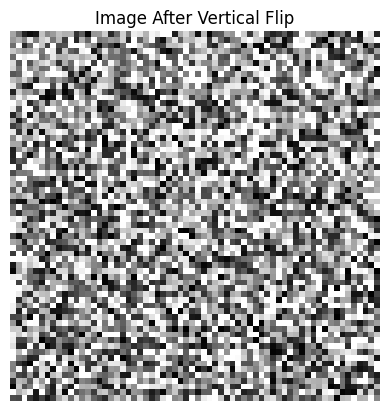

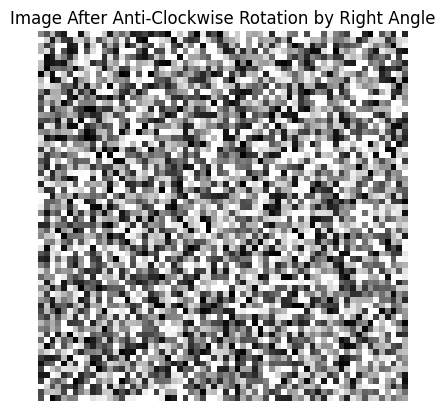

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Create a synthetic 64x64 "image" using np.random.randint(0, 256, (64, 64))
# ----------------------------------------------------------------------

np.random.seed(43)
image = np.random.randint(0, 256, (64,64))

plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()

# Implement brightness adjustment: add scalar, clip to [0, 255]
# ----------------------------------------------------------------------

image = np.clip(image + 34, 0, 255)

plt.imshow(image, cmap='gray')
plt.title("After Brightness Adjustment and Clipping")
plt.axis('off')
plt.show()

# Implement contrast stretching: min-max normalization to [0, 255]
# ----------------------------------------------------------------------
image = ((image - np.min(image))/(np.max(image) - np.min(image))) * 255

plt.imshow(image, cmap='gray')
plt.title("After Min-Max Normalization")
plt.axis('off')
plt.show()

# # Blurred Image (Valid region only)
# # ----------------------------------------------------------------------
# blurred_image = np.empty((62,62))
# for i in range(1, 63):
#     for j in range(1, 63):
#         matrix_for_mean = image[i-1: i+2, j-1: j+2]
#         assert matrix_for_mean.shape == (3, 3), "Shape mismatched"
#         # Passes Silently
#         blurred_image[i-1, j-1] = np.mean(matrix_for_mean)

# # ==================================================
# #           RANDOM TESTING (SANITY CHECKS)
# # ==================================================

# # Test-1 (i = 1, j = 1)
# assert np.allclose(np.mean(image[0:3, 0:3]), blurred_image[0,0]), \
# f"Values mismatched! Expected: {blurred_image[0,0]}, Found: {np.mean(image[0:3, 0:3])}"
# # Passes Silently

# # Test-2 (i = 32, j = 49)
# assert np.allclose(np.mean(image[31:34, 48:51]), blurred_image[31,48]), \
# f"Values mismatched! Expected: {blurred_image[31,48]}, Found: {np.mean(image[31:34, 48:51])}"
# # Passes Silently

# # Test-3 (i = 23, j = 60)
# assert np.allclose(np.mean(image[22:25, 59:62]), blurred_image[22,59]), \
# f"Values mismatched! Expected: {blurred_image[22,59]}, Found: {np.mean(image[22:25, 59:62])}"
# # Passes Silently

# Blurred Image (Same-size output image) -- Assisted by ChatGPT
# ----------------------------------------------------------------------

# assume image is your 64x64 input
h, w = image.shape

# # create padded image (mirror padding by 1 layer)
padded = np.zeros((h + 2, w + 2))

# # center copy
padded[1:-1, 1:-1] = image

# # mirror borders
padded[0, 1:-1] = image[0, :]        # top
padded[-1, 1:-1] = image[-1, :]      # bottom
padded[1:-1, 0] = image[:, 0]        # left
padded[1:-1, -1] = image[:, -1]      # right

# # corners
padded[0, 0] = image[0, 0]
padded[0, -1] = image[0, -1]
padded[-1, 0] = image[-1, 0]
padded[-1, -1] = image[-1, -1]

# # output image (same size as original)
blurred_image = np.empty((h, w))

# # sliding window blur
for i in range(h):
    for j in range(w):
        window = padded[i:i+3, j:j+3]
        blurred_image[i, j] = np.mean(window)

plt.imshow(blurred_image, cmap='gray')
plt.title("Blurred Image")
plt.axis('off')
plt.show()

# Detect "edges" by computing gradient magnitude using np.diff
# ----------------------------------------------------------------------

h_change = np.diff(image, axis=1)

plt.imshow(h_change, cmap='gray')
plt.title("Horizontal Gradient")
plt.axis('off')
plt.show()

v_change = np.diff(image, axis=0)

plt.imshow(v_change, cmap='gray')
plt.title("Vertical Gradient")
plt.axis('off')
plt.show()

# SANITY CHECKS
# print(h_change.shape)       # (64, 63)
# print(v_change.shape)       # (63, 64)

aligned_h = h_change[:63, :]
aligned_v = v_change[:, :63]

# SANITY CHECK
# assert aligned_h.shape == aligned_v.shape       # Passes silently

edge_strength = np.sqrt(np.square(aligned_h) + np.square(aligned_v))

plt.imshow(edge_strength, cmap='gray')
plt.title("Edge Strength (Detected Edges)")
plt.axis('off')
plt.show()

# Apply threshold segmentation using boolean indexing
# ----------------------------------------------------------------------

threshold = 128

segmentation = np.where(edge_strength > threshold, 1, 0)

plt.imshow(segmentation, cmap='gray')
plt.title("After Segmentation")
plt.axis('off')
plt.show()

# Flip horizontally and vertically using slicing
# ----------------------------------------------------------------------

h_flip = image[:, ::-1]

plt.imshow(h_flip, cmap='gray')
plt.title("Image After Horizontal Flip")
plt.axis('off')
plt.show()

v_flip = image[::-1, :]

plt.imshow(v_flip, cmap='gray')
plt.title("Image After Vertical Flip")
plt.axis('off')
plt.show()

# Rotate 90 degrees using np.rot90
# ----------------------------------------------------------------------

rotate_by90 = np.rot90(image)

plt.imshow(rotate_by90, cmap='gray')
plt.title("Image After Anti-Clockwise Rotation by Right Angle")
plt.axis('off')
plt.show()